**Exercice 1:**

In [ ]:
# Import de la bibliothèque NumPy
# NumPy est utilisée pour le calcul scientifique et la manipulation des tableaux (arrays)
import numpy as np

# Import de Matplotlib
# Matplotlib permet de créer des graphiques et visualisations (courbes, histogrammes, etc.)
import matplotlib.pyplot as plt

# Import de Keras depuis TensorFlow
# Keras est une API de haut niveau utilisée pour construire et entraîner des modèles de Deep Learning
from tensorflow import keras

**1. Chargement des données et Normalisation:**

In [ ]:
# Chargement du dataset MNIST depuis Keras
# MNIST contient des images de chiffres manuscrits (0 à 9)
# 60 000 images pour l'entraînement
# 10 000 images pour le test
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Affiche la dimension des données d'entraînement
# Format : (nombre_images, hauteur, largeur)
# Chaque image MNIST est de taille 28x28 pixels
print('trainset:', X_train.shape)  # (60000, 28, 28)

# Affiche la dimension des données de test
print('testset:', X_test.shape)  # (10000, 28, 28)



trainset: (60000, 28, 28)
testset: (10000, 28, 28)





**Normalisation des données: pour que le modèle gérer des valeurs proches**




In [ ]:
# Les pixels ont des valeurs entre 0(min) et 255(max)
# On divise par 255 (max) pour ramener les valeurs entre 0 et 1
# Cela améliore la stabilité et la performance du modèle
# xtrain=xtrain/max-min:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32')  / 255

print( X_train[1,:,:])
print(X_test[1,:,:])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

**2. Visualisation des données:**

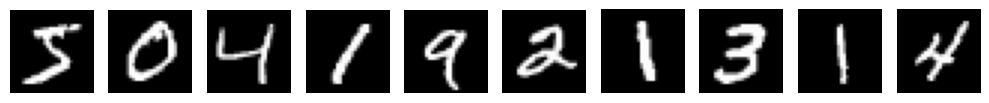

In [ ]:
# Visualisation de quelques images du dataset MNIST

# Création d'une figure avec 1 ligne et 10 colonnes
# figsize définit la taille de la figure (largeur, hauteur)
fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(10, 4))

# Boucle pour afficher les 10 premières images du dataset d'entraînement
for i in range(10):
    # Affichage de l'image i
    # cmap='gray' permet d'afficher l'image en niveaux de gris
    ax[i].imshow(X_train[i], cmap='gray')

    # Supprime les axes (optionnel mais plus propre visuellement)
    ax[i].axis('off')

# Ajuste automatiquement les espacements entre les images
plt.tight_layout()

# Affiche la figure à l'écran
plt.show()

**3. Configuration des Couches du Réseau de Neurones:**

 Image (28x28)
→
Flatten → (784)
→
Dense(128)
→
Dense(128)
→
Dense(10)
→
Probabilités des chiffres

In [ ]:
# Configuration des couches du réseau (architecture du modèle)
model = keras.Sequential([

    # Transforme chaque image 28x28 en un vecteur 1D de 784 valeurs
    # (28 × 28 = 784)
    keras.layers.Flatten(input_shape=(28, 28)),

    # Couche cachée avec 128 neurones
    # activation='relu' permet d’introduire la non-linéarité
    keras.layers.Dense(128, activation='relu'),

    # Deuxième couche cachée de 128 neurones
    keras.layers.Dense(64, activation='relu'),

    # Couche de sortie avec 10 neurones (un pour chaque chiffre 0–9)
    keras.layers.Dense(10)
])

# Affiche un résumé du modèle (nombre de paramètres, couches, etc.)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**4. Entrainement du Réseau de Neurones**

In [ ]:
# -----------------------------
# Compilation du modèle
# -----------------------------

# On configure comment le modèle va apprendre
model.compile(

    # Optimizer = méthode utilisée pour ajuster les poids
    # Adam est un des meilleurs optimiseurs par défaut (rapide et stable)
    optimizer='adam',

    # Loss = fonction d’erreur
    # Elle mesure à quel point les prédictions sont fausses
    # SparseCategoricalCrossentropy est utilisée pour classification multi-classes
    # from_logits=True car la dernière couche n’a pas de softmax
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),

    # Métrique d’évaluation
    # Accuracy = pourcentage de bonnes prédictions
    metrics=['accuracy']
)

# -----------------------------
# Entraînement du modèle
# -----------------------------

# epochs = nombre de fois où le modèle voit tout le dataset
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8724 - loss: 0.4335
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9680 - loss: 0.1025
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9779 - loss: 0.0709
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9827 - loss: 0.0514
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9872 - loss: 0.0408
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9901 - loss: 0.0304
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9909 - loss: 0.0267
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9932 - loss: 0.0214
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9951 - loss: 0.0159
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9946 - loss: 0.0162


**5. Évaluation du réseau de neurone sur les données de Test:**

In [ ]:
# Evaluation du modele
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.1179
Test accuracy: 0.9779000282287598


**6. Création d'un modele prédictif:**

In [ ]:
# modele prédictif (softmax)
prediction_model = keras.Sequential([model, keras.layers.Softmax()])
predict_proba = prediction_model.predict(X_test)
predictions = np.argmax(predict_proba, axis=1)
print(predictions[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


**Exercice 2:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# -----------------------------
# make_blobs(النقط) est une fonction qui permet de générer des données artificielles pour tester des algorithmes de Machine Learning.
# -----------------------------

#Elle crée : Des points (features),Regroupés en plusieurs clusters (groupes),Avec des labels (classes)
#On l’utilise souvent pour :Tester le clustering (K-Means),Tester la classification,Visualiser des données 2D

1. chargement de dataset depuis make blobs

dimensions de X: (100, 2)
dimensions de y: (100, 1)


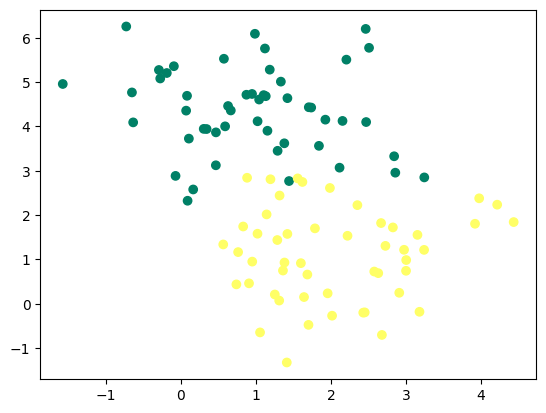

In [ ]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2,random_state=0)
y = y.reshape((y.shape[0], 1))
print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)
plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

In [ ]:
#Elle sert à initialiser les paramètres du modèle :
#entré X qui est la matrice des données.
def initialisation(X):
  #W poids
  W = np.random.randn(X.shape[1], 1)
  #b biais
  b = np.random.randn(1)
  return (W, b)

In [ ]:
def model(X, W, b):
  #Z=XW+b
  Z = X.dot(W) + b
  #Puis on applique la fonction sigmoïde :𝐴=𝜎(𝑍)=1/1+𝑒− 𝑍A=σ(Z)=1+e−Z1	​
  #Pourquoi utiliser la sigmoïde ? Parce qu’en classification binaire :On veut une sortie entre 0 et 1,Interprétable comme probabilit

  A = 1 / (1 + np.exp(-Z))
  return A

In [ ]:
#Elle mesure l’erreur du modèle.
def log_loss(A, y):
  return 1 / len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 -A))

In [ ]:
def gradients(A, X, y):
    m = len(y)  # nombre d'exemples

    # Gradient par rapport aux poids
    dW = 1 / m * np.dot(X.T, A - y)

    # Gradient par rapport au biais
    db = 1 / m * np.sum(A - y)

    return (dW, db)


def update(dW, db, W, b, learning_rate):

    # Mise à jour des paramètres avec descente de gradient
    W = W - learning_rate * dW
    b = b - learning_rate * db

    return (W, b)

In [ ]:
def predict(X, W, b):
  A = model(X, W, b)
# print(A)
  return A >= 0.5

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:

def artificial_neuron(X, y, learning_rate = 0.1, n_iter = 100):
# initialisation W, b
  W, b = initialisation(X)
  Loss = []
  for i in range(n_iter):
     A = model(X, W, b)
     Loss.append(log_loss(A, y))
     dW, db = gradients(A, X, y)
     W, b = update(dW, db, W, b, learning_rate)
  y_pred = predict(X, W, b)
  print(accuracy_score(y, y_pred))
  plt.plot(Loss)
  plt.show()
  return (W, b)


0.89


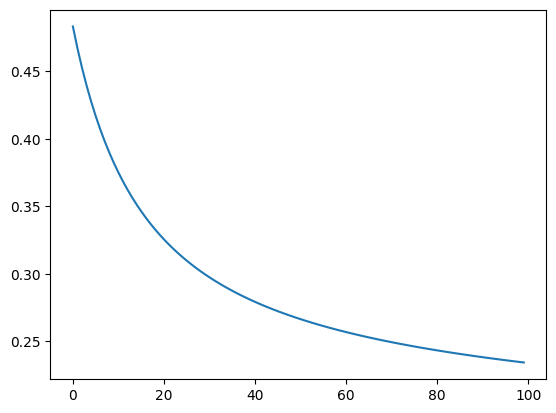

In [ ]:
W, b = artificial_neuron(X, y)

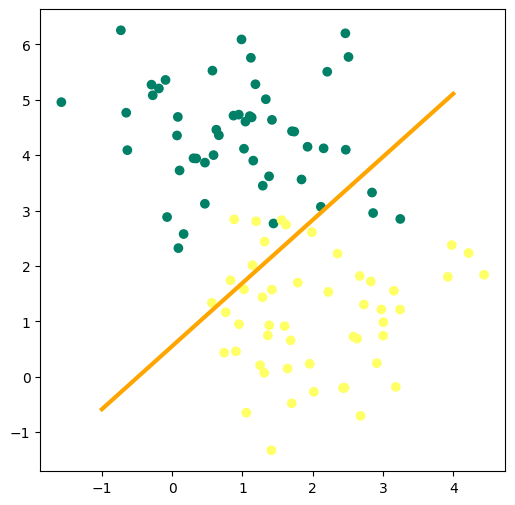

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
x1 = np.linspace(-1, 4, 100)
x2 = ( - W[0] * x1 - b) / W[1]
ax.plot(x1, x2, c='orange', lw=3)

**Exercice3**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/AmesHousing.csv"

df = pd.read_csv(path)

df.head()

Mounted at /content/drive


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


pour afficher la taille de dataset



In [ ]:
df.shape

(2930, 82)

In [ ]:
#Valeurs manquantes
VM = pd.DataFrame({
 'Colonne': df.columns.values,
 'nbr de VM': df.isna().sum().values,
 '% de VM': 100 * df.isna().sum().values / len(df),})
VM = VM[VM['nbr de VM'] > 0]
print(VM.sort_values(by='nbr de VM',ascending=False).reset_index(drop=True))

           Colonne  nbr de VM    % de VM
0          Pool QC       2917  99.556314
1     Misc Feature       2824  96.382253
2            Alley       2732  93.242321
3            Fence       2358  80.477816
4     Mas Vnr Type       1775  60.580205
5     Fireplace Qu       1422  48.532423
6     Lot Frontage        490  16.723549
7      Garage Qual        159   5.426621
8      Garage Cond        159   5.426621
9    Garage Yr Blt        159   5.426621
10   Garage Finish        159   5.426621
11     Garage Type        157   5.358362
12   Bsmt Exposure         83   2.832765
13  BsmtFin Type 2         81   2.764505
14       Bsmt Cond         80   2.730375
15       Bsmt Qual         80   2.730375
16  BsmtFin Type 1         80   2.730375
17    Mas Vnr Area         23   0.784983
18  Bsmt Full Bath          2   0.068259
19  Bsmt Half Bath          2   0.068259
20    BsmtFin SF 1          1   0.034130
21    BsmtFin SF 2          1   0.034130
22      Electrical          1   0.034130
23   Total Bsmt 

In [ ]:

# Afficher
print(VM)

           Colonne  nbr de VM    % de VM
4     Lot Frontage        490  16.723549
7            Alley       2732  93.242321
26    Mas Vnr Type       1775  60.580205
27    Mas Vnr Area         23   0.784983
31       Bsmt Qual         80   2.730375
32       Bsmt Cond         80   2.730375
33   Bsmt Exposure         83   2.832765
34  BsmtFin Type 1         80   2.730375
35    BsmtFin SF 1          1   0.034130
36  BsmtFin Type 2         81   2.764505
37    BsmtFin SF 2          1   0.034130
38     Bsmt Unf SF          1   0.034130
39   Total Bsmt SF          1   0.034130
43      Electrical          1   0.034130
48  Bsmt Full Bath          2   0.068259
49  Bsmt Half Bath          2   0.068259
58    Fireplace Qu       1422  48.532423
59     Garage Type        157   5.358362
60   Garage Yr Blt        159   5.426621
61   Garage Finish        159   5.426621
62     Garage Cars          1   0.034130
63     Garage Area          1   0.034130
64     Garage Qual        159   5.426621
65     Garage Co

In [ ]:
# on affiche les variables catégorielles et les variables numériques

colonnes_avec_VM = df.columns[df.isna().sum() > 0]

for col in colonnes_avec_VM:
    print(col)
    print(df[col].unique()[:5])
    print('*'*30)

Lot Frontage
[141.  80.  81.  93.  74.]
******************************
Alley
[nan 'Pave' 'Grvl']
******************************
Mas Vnr Type
['Stone' nan 'BrkFace' 'BrkCmn' 'CBlock']
******************************
Mas Vnr Area
[112.   0. 108.  20. 603.]
******************************
Bsmt Qual
['TA' 'Gd' 'Ex' nan 'Fa']
******************************
Bsmt Cond
['Gd' 'TA' nan 'Po' 'Fa']
******************************
Bsmt Exposure
['Gd' 'No' 'Mn' 'Av' nan]
******************************
BsmtFin Type 1
['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf']
******************************
BsmtFin SF 1
[ 639.  468.  923. 1065.  791.]
******************************
BsmtFin Type 2
['Unf' 'LwQ' 'BLQ' 'Rec' nan]
******************************
BsmtFin SF 2
[   0.  144. 1120.  163.  168.]
******************************
Bsmt Unf SF
[ 441.  270.  406. 1045.  137.]
******************************
Total Bsmt SF
[1080.  882. 1329. 2110.  928.]
******************************
Electrical
['SBrkr' 'FuseA' 'FuseF' 'FuseP' nan]
***

In [ ]:
#on remplace les VM numériques par la moyenne de la colonne
num_VM = ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']
for n_col in num_VM:
   df[n_col] = df[n_col].fillna(df[n_col].mean())

In [ ]:
#On remplace les VM nominales par le mode variable
nom_VM = [x for x in colonnes_avec_VM if x not in num_VM]
for nom_col in nom_VM:
  df[nom_col] = df[nom_col].fillna(df[nom_col].mode().to_numpy()[0])

In [ ]:
#encodage des variables catégorielles
#on affiche tout d'abord les types de données pour chaque colonne
types = pd.DataFrame({
'Colonne': df.select_dtypes(exclude='object').columns.values,
'Type': df.select_dtypes(exclude='object').dtypes.values})
print(types)


            Colonne     Type
0             Order    int64
1               PID    int64
2       MS SubClass    int64
3      Lot Frontage  float64
4          Lot Area    int64
5      Overall Qual    int64
6      Overall Cond    int64
7        Year Built    int64
8    Year Remod/Add    int64
9      Mas Vnr Area  float64
10     BsmtFin SF 1  float64
11     BsmtFin SF 2  float64
12      Bsmt Unf SF  float64
13    Total Bsmt SF  float64
14       1st Flr SF    int64
15       2nd Flr SF    int64
16  Low Qual Fin SF    int64
17      Gr Liv Area    int64
18   Bsmt Full Bath  float64
19   Bsmt Half Bath  float64
20        Full Bath    int64
21        Half Bath    int64
22    Bedroom AbvGr    int64
23    Kitchen AbvGr    int64
24    TotRms AbvGrd    int64
25       Fireplaces    int64
26    Garage Yr Blt  float64
27      Garage Cars  float64
28      Garage Area  float64
29     Wood Deck SF    int64
30    Open Porch SF    int64
31   Enclosed Porch    int64
32       3Ssn Porch    int64
33     Screen 

In [ ]:
#encodage des variables catégorielles,
#selon le descriptif de la dataset la colonne MS SubClass est nominale,
#Pandas a du mal à retourner son vrai type
df['MS SubClass'] = df['MS SubClass'].astype(str)
selection_de_variables = ['MS SubClass', 'MS Zoning', 'Lot Frontage',
'Lot Area','Neighborhood', 'Overall Qual', 'Overall Cond',
'Year Built', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF',
'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
'Kitchen AbvGr', 'TotRms AbvGrd', 'Garage Area',
'Pool Area', 'SalePrice']
df = df[selection_de_variables]
#la dataset comprendera maintenant que 67 variables
df = pd.get_dummies(df)

In [ ]:
#fractionner dataset en des données de test et de train
train = df.sample(frac = 0.8, random_state = 9)
test = df.drop(train.index)
#variable cible
train_cible = train.pop('SalePrice')
test_cible = test.pop('SalePrice')

In [ ]:
#Standardisation
variables_pred = train.columns
for col in variables_pred:
   col_moyenne = train[col].mean()
   col_ecart_type = train[col].std()
   if col_ecart_type == 0:
     col_ecart_type = 1e-20
   train[col] = (train[col] - col_moyenne) / col_ecart_type
   test[col] = (test[col] - col_moyenne) / col_ecart_type

In [ ]:
modele = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[train.shape[1]]),
    keras.layers.Dropout(0.3, seed=2),
    keras.layers.Dense(64, activation='swish'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='swish'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='swish'),
    keras.layers.Dense(1)
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Création de l’optimiseur Adam:**

Un optimiseur est l’algorithme qui aide le réseau de neurones à ajuster ses poids pour réduire l’erreur.

In [ ]:
optimiseur = tf.keras.optimizers.Adam(learning_rate=0.001)

Le modèle est compilé en utilisant l’optimiseur Adam avec un taux d’apprentissage de 0.001. La fonction de perte utilisée est l’erreur quadratique moyenne (MSE) et la métrique utilisée pour l’évaluation est l’erreur absolue moyenne (MAE). Ensuite, le modèle est entraîné à l’aide de la fonction fit() sur les données d’entraînement pendant 70 époques, avec 20% des données utilisées pour la validation.

In [ ]:
# Compile the model
modele.compile(
    optimizer=optimiseur,
    loss='mse',
    metrics=['mae']
)

# Entraînement
training = modele.fit(train,train_cible, epochs=70, validation_split=0.2)


Epoch 1/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 39575707648.0000 - mae: 182285.3125 - val_loss: 39983972352.0000 - val_mae: 181497.9219
Epoch 2/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31660709888.0000 - mae: 159153.5000 - val_loss: 1929185664.0000 - val_mae: 30710.6777
Epoch 3/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2188937216.0000 - mae: 33712.4258 - val_loss: 1473251200.0000 - val_mae: 23501.4121
Epoch 4/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2162053120.0000 - mae: 29439.4980 - val_loss: 1413751296.0000 - val_mae: 22946.5430
Epoch 5/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1728871040.0000 - mae: 28485.2812 - val_loss: 1304246016.0000 - val_mae: 21662.7539
Epoch 6/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1948152832.0000 - mae: 27987.3750 - val_loss: 1389263232.0000 - val_mae: 22476.0801
Epoch 7/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1471420288.0000 - mae: 26839.9375 - val_loss: 1297338240.0000 - val_mae: 21240.7188


Qu’est-ce que EarlyStopping ?

C’est une technique pour éviter le surapprentissage (overfitting),elle permet d’arrêter automatiquement l'entraînement quand le modèle n'améliore plus ses performances.

In [ ]:
#autre partie
# 9. Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# 10. Entraînement
history = modele.fit(
    train,
    train_cible,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

# 11. Évaluation
loss, mae = modele.evaluate(test, test_cible, verbose=0)
print("MSE :", loss)
print("MAE :", mae)

# 12. Prédictions
#des prédictions sont réalisées sur les données de test.
predictions = modele.predict(test)
print(predictions[:5])

Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 598781440.0000 - mae: 16717.5332 - val_loss: 758767296.0000 - val_mae: 16824.0469
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 698333312.0000 - mae: 17900.6289 - val_loss: 818018112.0000 - val_mae: 17150.8945
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 586422016.0000 - mae: 16926.4062 - val_loss: 851738688.0000 - val_mae: 17477.8984
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 589370752.0000 - mae: 16967.7266 - val_loss: 837579968.0000 - val_mae: 17367.6250
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 607079680.0000 - mae: 17056.3594 - val_loss: 829899392.0000 - val_mae: 17058.3633
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 683538496.0000 - mae: 17588.6191 - val_loss: 816556480.0000 - val_mae: 17592.6406
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 624796288.0000 - mae: 17681.8184 - val_loss: 782186944.0000 - val_mae: 16919.4961
Epoch 8/200
5

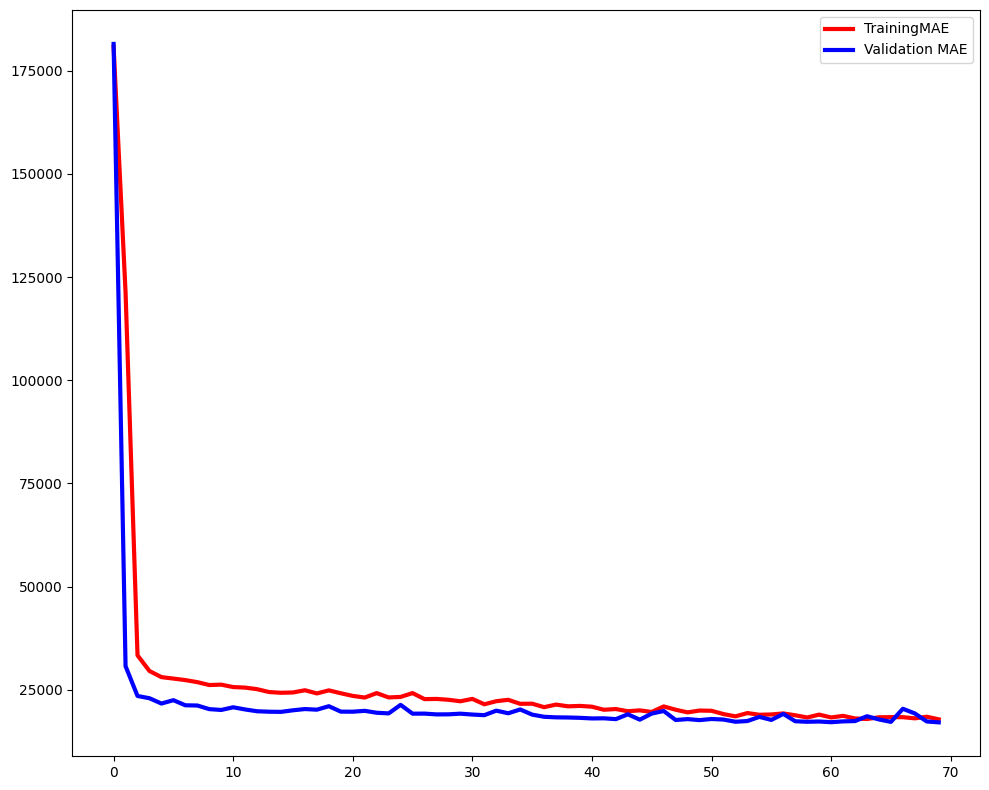

In [ ]:
historique = pd.DataFrame(training.history)
historique['epoque'] = training.epoch
figure, axe = plt.subplots(figsize = (10,8))
num_epoque = historique.shape[0]
axe.plot(np.arange(0, num_epoque), historique["mae"],label = "TrainingMAE", lw = 3, color = 'red')
axe.plot(np.arange(0, num_epoque), historique["val_mae"],label =
"Validation MAE", lw = 3, color = 'blue')
axe.legend ()
plt.tight_layout()
plt.show()

Le graphique représente l’évolution de l’erreur absolue moyenne (MAE) pendant l’entraînement du modèle. On observe une forte diminution de l’erreur au début de l’apprentissage, ce qui indique que le modèle apprend rapidement les relations entre les variables. Ensuite, les courbes se stabilisent autour d’une valeur proche de 18 000. Les courbes d’entraînement et de validation étant très proches, cela indique que le modèle généralise bien et ne présente pas de surapprentissage significatif.

Le résultat prédit a été comparé à la valeur réelle du dataset afin d’évaluer la précision du modèle.

In [ ]:
test1 = test.iloc[[10]]
test_prediction = modele.predict(test1).squeeze()
test_label = test_cible.iloc[10]
print("Prédiction du modèle = {:.2f}".format(test_prediction))
print("Valeur actuelle = {:.2f}".format(test_label))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Prédiction du modèle = 311070.38
Valeur actuelle = 259000.00
